# Per-character TF-IDF: 10 main POV characters

Mirrors the house-level TF-IDF but at the **character** level. Each character's document = `bio + quotes`. IDF is taken over the 10-character corpus so a word that appears in every character's writing gets zero weight; a word distinctive to one character (e.g. Daenerys' Valyrian terms, Tyrion's wine vocabulary, Davos' Flea-Bottom slang) rises to the top.

Character names are filtered from tokens - otherwise `tyrion`, `cersei`, etc. dominate trivially. House names are kept (they're informative: 'lannister' is a distinctive Tyrion token, 'targaryen' for Daenerys).

Reads `characters_enriched_v2.csv`, `characters_bio.csv`, and `characters_quotes.csv`.

In [11]:
import math
import os
import string
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

stop_words = set(stopwords.words('english'))


## Load data and pick the 10 main characters
Canonical POV characters from Books 1-5, spanning multiple houses and regions.

In [12]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
bios_df = pd.read_csv('../csvs/characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

if os.path.exists('../csvs/characters_quotes.csv'):
    quotes_df = pd.read_csv('../csvs/characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(lambda s: ' '.join(s)).to_dict()
    print(f'Loaded {len(quotes_df)} quotes attributed to {len(quotes)} distinct speakers')
else:
    quotes = {}
    print('characters_quotes.csv not found - running on bios only')

MAIN_CHARACTERS = [
    'Jon_Snow',
    'Cersei_Lannister',
    'Daenerys_Targaryen',
    'Tyrion_Lannister',
    'Petyr_Baelish',     # Littlefinger
    'Theon_Greyjoy',
    'Melisandre',
    'Walder_Frey',
    'Davos_Seaworth',
    'Robb_Stark',
]

valid_ids = set(df['ID'])
missing = [c for c in MAIN_CHARACTERS if c not in valid_ids]
if missing:
    print(f'WARNING: not found in v2 character set: {missing}')
MAIN_CHARACTERS = [c for c in MAIN_CHARACTERS if c in valid_ids]
name_by_id = dict(zip(df['ID'], df['name']))

for cid in MAIN_CHARACTERS:
    bio_len = len(bios.get(cid, ''))
    q_len = len(quotes.get(cid, ''))
    print(f'  {name_by_id[cid]:25s}  bio: {bio_len:>6} chars   quotes: {q_len:>5} chars')


Loaded 4275 quotes attributed to 505 distinct speakers
  Jon Snow                   bio:  26336 chars   quotes: 51133 chars
  Cersei Lannister           bio:  26347 chars   quotes: 35129 chars
  Daenerys Targaryen         bio:  39275 chars   quotes: 31221 chars
  Tyrion Lannister           bio:  19604 chars   quotes: 49279 chars
  Petyr Baelish              bio:  17534 chars   quotes: 14986 chars
  Theon Greyjoy              bio:  17155 chars   quotes: 21354 chars
  Melisandre                 bio:  13644 chars   quotes:  3522 chars
  Walder Frey                bio:   6283 chars   quotes:  5427 chars
  Davos Seaworth             bio:  16531 chars   quotes: 16713 chars
  Robb Stark                 bio:  20260 chars   quotes:  7956 chars


## Build per-character corpus + tokenize
Same tokenization as the house TF-IDF: lowercase, NLTK word_tokenize, drop stopwords/punctuation, keep alpha-only. **Plus a character-name filter** built from every token appearing in any character's display name.

In [13]:
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        cleaned = part.strip(string.punctuation)
        if cleaned and cleaned.isalpha() and len(cleaned) > 2:
            character_name_tokens.add(cleaned)
print(f'Character-name filter: {len(character_name_tokens)} tokens')

from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import MWETokenizer


def base_tokenize(text):
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words
            and w not in string.punctuation
            and w.isalpha()
            and w not in character_name_tokens
            and len(w) > 2]


# Discover collocations on the whole AWOIAF corpus, not just the 10 mains.
# Larger corpus → more stable bigram statistics. Mirrors week 7 of the course.
all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)
collocations = finder.nbest(bigram_measures.chi_sq, 100)
print(f'Found {len(collocations)} significant bigrams. Top 15:')
for w1, w2 in collocations[:15]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')


def tokenize(text):
    return mwe.tokenize(base_tokenize(text))


char_tokens = {}
for cid in MAIN_CHARACTERS:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    char_tokens[cid] = tokenize(text)

for cid in MAIN_CHARACTERS:
    print(f'  {name_by_id[cid]:25s} {len(char_tokens[cid]):>6} tokens')


Character-name filter: 3033 tokens
Found 100 significant bigrams. Top 15:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  brotherhood_banners
  iron_throne
  Jon Snow                    4806 tokens
  Cersei Lannister            3572 tokens
  Daenerys Targaryen          4477 tokens
  Tyrion Lannister            4137 tokens
  Petyr Baelish               1823 tokens
  Theon Greyjoy               2289 tokens
  Melisandre                   960 tokens
  Walder Frey                  615 tokens
  Davos Seaworth              1975 tokens
  Robb Stark                  1599 tokens


## Compute TF, IDF, TF-IDF
TF: term frequency normalized by document length. IDF: log(N / docs containing the word), N=10 here. So a word that appears in all 10 characters gets IDF=0 and TF-IDF=0 - distinctive words rise.

In [14]:
tf_char = {}
for cid, tokens in char_tokens.items():
    if not tokens:
        tf_char[cid] = {}
        continue
    counts = Counter(tokens)
    total = len(tokens)
    tf_char[cid] = {w: c / total for w, c in counts.items()}

N = len(char_tokens)
doc_freq = Counter()
for tokens in char_tokens.values():
    for w in set(tokens):
        doc_freq[w] += 1
idf = {w: math.log(N / doc_freq[w]) for w in doc_freq}

tfidf_char = {cid: {w: tf * idf.get(w, 0) for w, tf in vals.items()}
              for cid, vals in tf_char.items()}

# Sanity: top 10 for each character
TOP = 10
for cid in MAIN_CHARACTERS:
    top = sorted(tfidf_char[cid].items(), key=lambda x: x[1], reverse=True)[:TOP]
    print(f'\n{name_by_id[cid]}:')
    for w, s in top:
        print(f'  {s:.5f}  {w}')



Jon Snow:
  0.00426  wildling
  0.00383  chosen
  0.00356  wall
  0.00326  crow
  0.00301  vows
  0.00287  giants
  0.00255  wildlings
  0.00240  giantsbane
  0.00240  thenn
  0.00240  southron

Cersei Lannister:
  0.00387  sins
  0.00315  trial
  0.00258  twin
  0.00258  accusations
  0.00258  morrows
  0.00233  casterly_rock
  0.00194  faith
  0.00193  hears
  0.00193  throughout
  0.00193  valonqar

Daenerys Targaryen:
  0.01234  khalasar
  0.01222  meereen
  0.00935  yunkai
  0.00874  khal
  0.00720  drogon
  0.00655  dragon
  0.00617  harpy
  0.00575  dothraki
  0.00566  khaleesi
  0.00539  astapor

Tyrion Lannister:
  0.00445  duck
  0.00334  clansmen
  0.00311  griff
  0.00311  volantis
  0.00278  imp
  0.00233  hollow
  0.00223  inn
  0.00223  reigned
  0.00223  tool
  0.00223  sounds

Petyr Baelish:
  0.01501  littlefinger
  0.01056  vale
  0.00632  protector
  0.00603  eyrie
  0.00505  lords_declarant
  0.00505  pinch
  0.00505  perfectly
  0.00441  sweetling
  0.00379  smal

## Word clouds - one per character
2 × 5 grid in the canonical reading order.

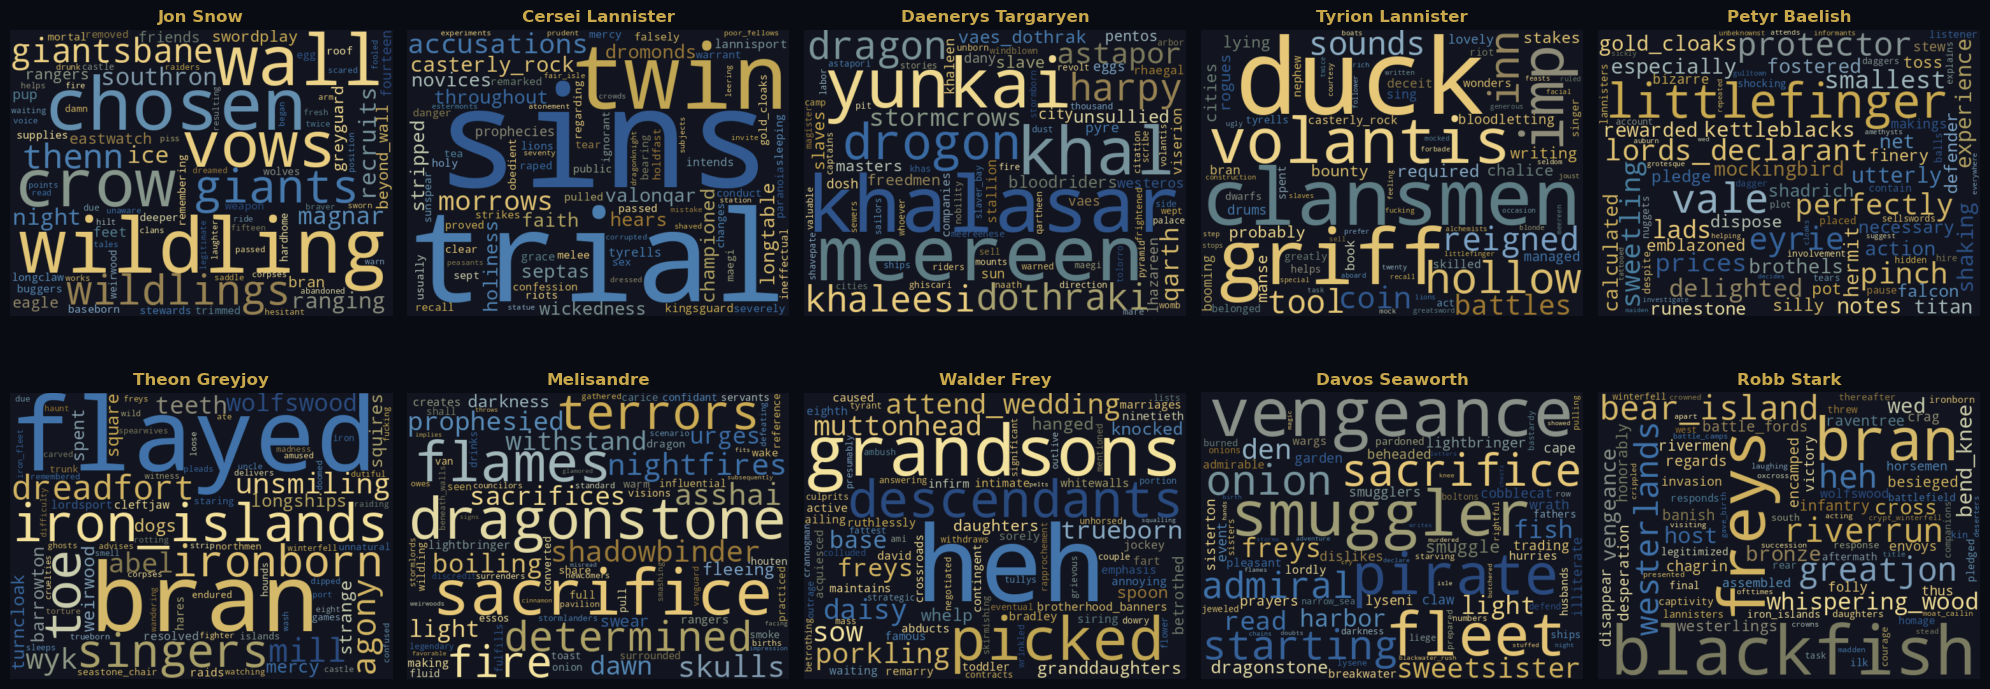

In [17]:
import random
from matplotlib.colors import LinearSegmentedColormap
karma_colors = [
    "#2A4A7F",   # deep navy blue
    "#3D6FA8",   # medium blue
    "#5B8DB8",   # lighter blue
    "#C9A84C",   # deep gold
    "#D4B86A",   # warm gold
    "#E8C97A",   # bright gold
    "#F5E4A0",   # pale gold
    "#7BA3C8",   # steel blue
    "#A07830",   # dark gold-brown
    "#4A7FA0",   # teal-blue
]
karma_cmap = LinearSegmentedColormap.from_list("karma", karma_colors)

def karma_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    t = random.Random(word).random()
    r, g, b, _ = karma_cmap(t)
    return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

n_cols = 5
n_rows = math.ceil(len(MAIN_CHARACTERS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig.patch.set_facecolor('#0a0c14')
axes = axes.flatten()

for ax, cid in zip(axes, MAIN_CHARACTERS):
    ax.set_facecolor('#12151f')
    scores = tfidf_char[cid]
    if not scores:
        ax.set_title(f'{name_by_id[cid]}\n(no text)', color='#C9A84C')
        ax.set_axis_off()
        continue
    wc = WordCloud(width=600, height=450, background_color='#12151f',
                   color_func=karma_color_func, max_words=80, prefer_horizontal=0.9)
    wc.generate_from_frequencies(scores)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name_by_id[cid], fontsize=12, fontweight='bold', color='#C9A84C')
    ax.set_axis_off()

for ax in axes[len(MAIN_CHARACTERS):]:
    ax.set_facecolor('#0a0c14')
    ax.set_axis_off()

plt.tight_layout()

from pathlib import Path
out_path = Path('../website/figures/word_clouds/main_cr_cloud.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out_path}')
plt.show()

## Distinctiveness table
Top-5 TF-IDF tokens for each character side-by-side. Quick scan for cross-character contrasts.

In [ ]:
rows = []
for cid in MAIN_CHARACTERS:
    top5 = sorted(tfidf_char[cid].items(), key=lambda x: x[1], reverse=True)[:5]
    rows.append({'character': name_by_id[cid],
                 **{f'top_{i+1}': w for i, (w, _) in enumerate(top5)}})
print(pd.DataFrame(rows).to_string(index=False))


         character        top_1       top_2        top_3       top_4           top_5
          Jon Snow     wildling      chosen         wall        crow            vows
  Cersei Lannister         sins       trial         twin accusations         morrows
Daenerys Targaryen     khalasar     meereen       yunkai        khal          drogon
  Tyrion Lannister         duck    clansmen        griff    volantis             imp
     Petyr Baelish littlefinger        vale    protector       eyrie lords_declarant
     Theon Greyjoy       flayed        bran iron_islands         toe         singers
        Melisandre    sacrifice dragonstone       flames     terrors            fire
       Walder Frey          heh   grandsons       picked descendants  attend_wedding
    Davos Seaworth    vengeance    smuggler        fleet      pirate       sacrifice
        Robb Stark    blackfish       freys         bran bear_island        greatjon
